In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("heart_disease_uci.csv")

# Show first rows
display(df.head())

# Check shape
print("Shape:", df.shape)

# Check missing values
print(df.isnull().sum())

# Check class distribution
print(df['num'].value_counts())

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Shape: (920, 16)
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [3]:
# (1) Drop ID column (identifier, not a predictive feature)
if "id" in df.columns:
    df = df.drop(columns=["id"])

# (2) Handle boolean columns that may be stored as object due to missing values
# Convert to 0/1 so models can use them
for col in ["fbs", "exang"]:
    if col in df.columns:
        df[col] = df[col].fillna(False).astype(int)

# (3) Convert target `num` (0–4) to binary: 0 = no disease, 1 = disease
df["num"] = pd.to_numeric(df["num"], errors="coerce")
df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

# (4) One-hot encode categorical/text columns (e.g., sex, cp, thal)
df = pd.get_dummies(df, drop_first=True)

df = df.fillna(df.median(numeric_only=True))

# (5) Split features/target
X = df.drop("num", axis=1)
y = df["num"]

print("Any non-numeric columns left?", X.select_dtypes(include="object").columns.tolist())
print("Target distribution:\n", y.value_counts())

Any non-numeric columns left? []
Target distribution:
 num
1    509
0    411
Name: count, dtype: int64


/var/folders/9k/z5cknj9j3jdc56sdnyy1cz8m0000gn/T/ipykernel_86710/2162922976.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).astype(int)
/var/folders/9k/z5cknj9j3jdc56sdnyy1cz8m0000gn/T/ipykernel_86710/2162922976.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(False).astype(int)


In [4]:
#Split Into Training and Testing
from sklearn.model_selection import train_test_split

X = df.drop("num", axis=1)
y = df["num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [11]:
#Logistic Regression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.84      0.74      0.79        82
           1       0.81      0.88      0.85       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.82       184
weighted avg       0.82      0.82      0.82       184

[[61 21]
 [12 90]]


In [6]:
df = pd.read_csv("heart_disease_uci.csv")

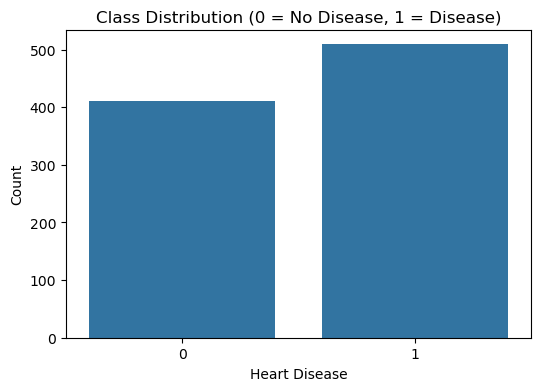

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=y)

plt.title("Class Distribution (0 = No Disease, 1 = Disease)")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

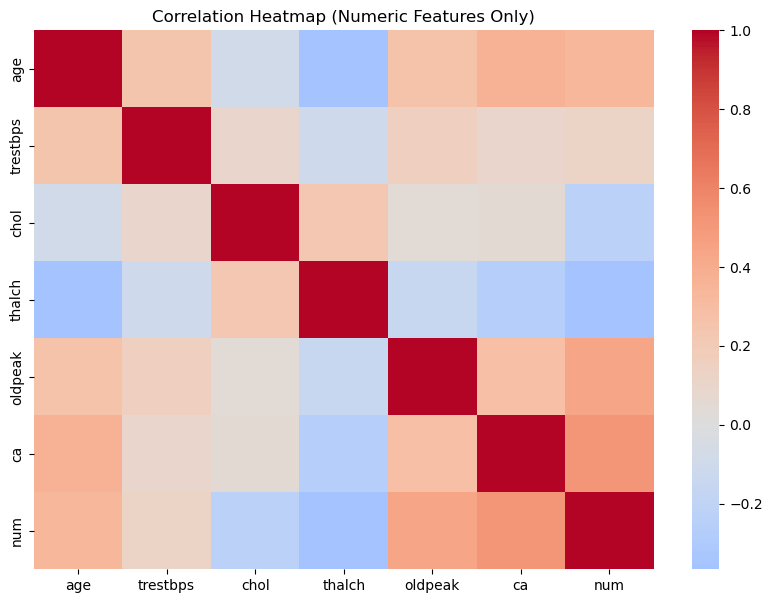

In [10]:
#Show correlations.
import matplotlib.pyplot as plt
import seaborn as sns

# Remove ID column if it exists
if "id" in df.columns:
    df = df.drop(columns=["id"])

# Keep only numeric columns
df_numeric = df.select_dtypes(include="number")

# Create correlation matrix
corr = df_numeric.corr()

# Plot heatmap
plt.figure(figsize=(10,7))
sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()